## Домашняя работа по базовой математической статистике для Data scientist

Задания со зведочкой не обязательны для зачета.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kurtosis
from scipy.stats import skew
from scipy import stats


df = pd.read_csv("bikeshare.csv")
del df['datetime']
df

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
10881,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


### 1.
Постройте гистограмму распределения каждой из метрик в датасете при помощи метода датафрейма `hist()`. При необходимости добавьте логарифмированную ось (параметр log).

<Axes: >

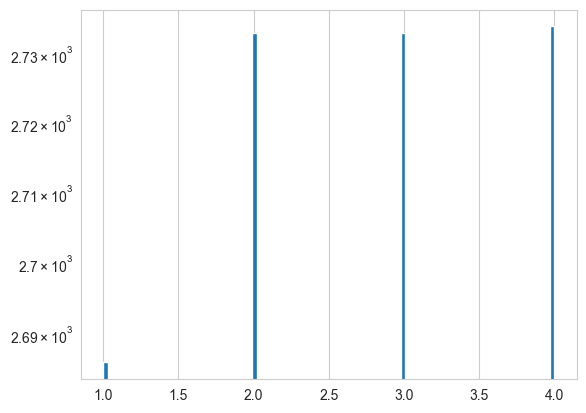

In [9]:
### YOUR CODE HERE ###
df['season'].hist(bins=100, log=True)

<Axes: >

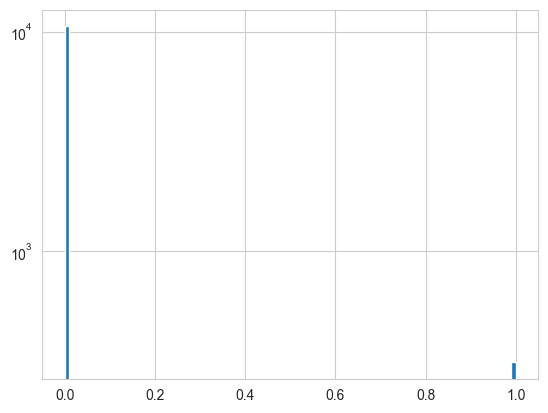

In [10]:
df['holiday'].hist(bins=100, log=True)

<Axes: >

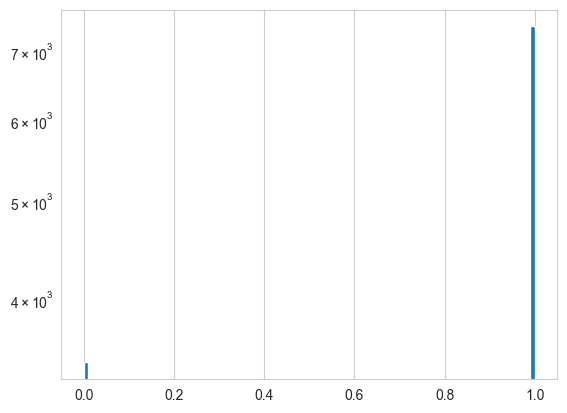

In [11]:
df['workingday'].hist(bins=100, log=True)

<Axes: >

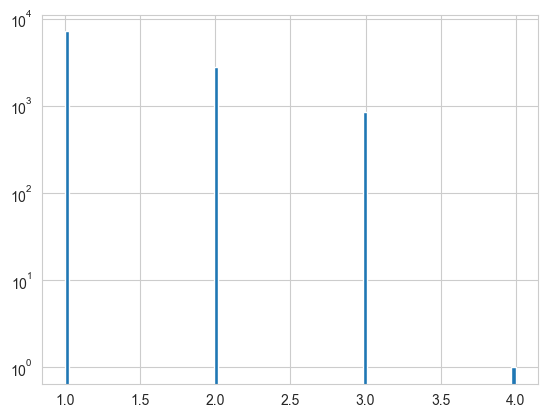

In [12]:
df['weather'].hist(bins=100, log=True)

<Axes: >

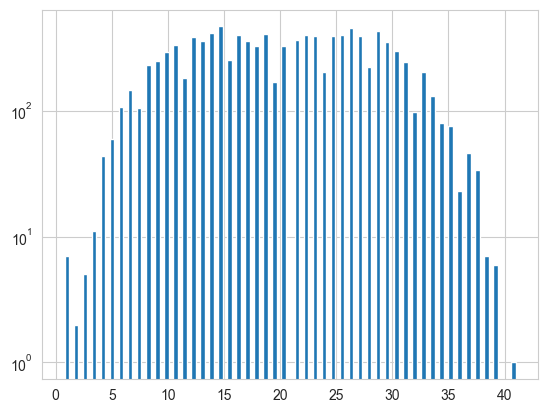

In [14]:
df['temp'].hist(bins=100, log=True)

<Axes: >

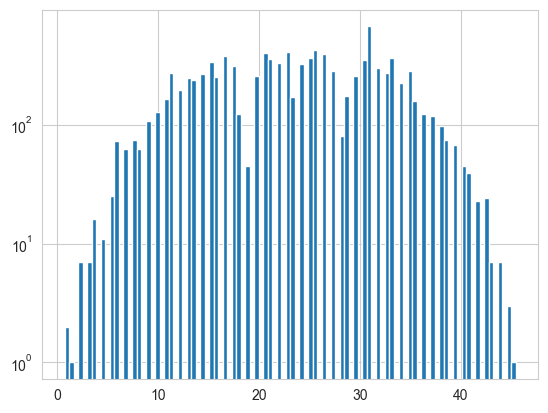

In [15]:
df['atemp'].hist(bins=100, log=True)

<Axes: >

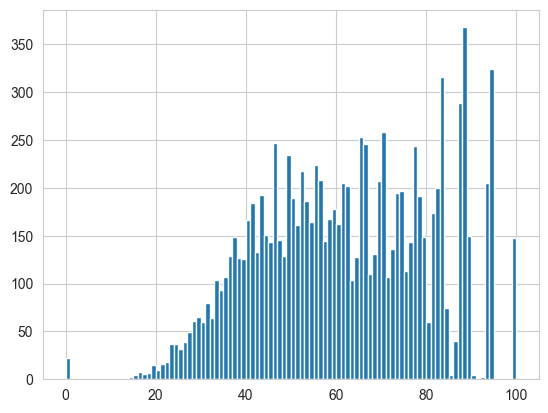

In [16]:
df['humidity'].hist(bins=100)

<Axes: >

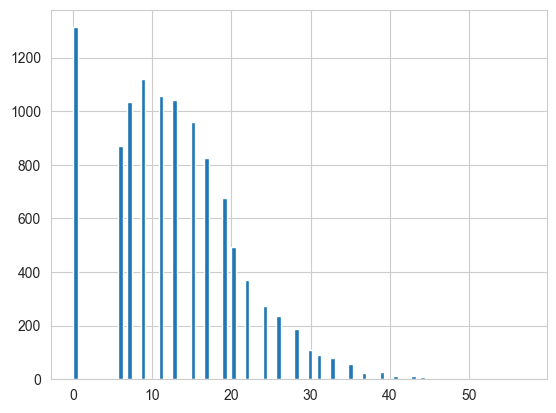

In [17]:
df['windspeed'].hist(bins=100)

<Axes: >

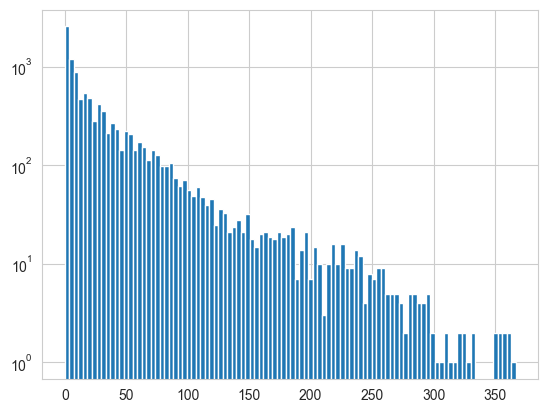

In [19]:
df['casual'].hist(bins=100, log=True)

<Axes: >

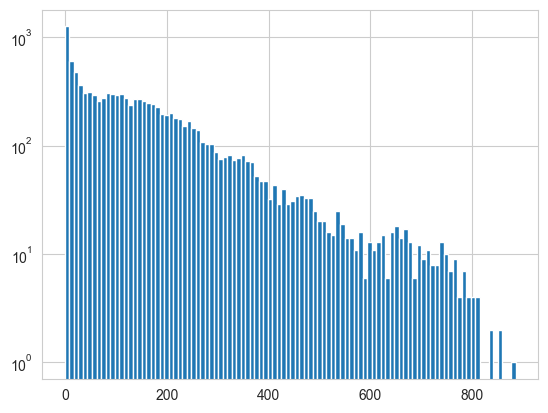

In [21]:
df['registered'].hist(bins=100, log=True)

<Axes: >

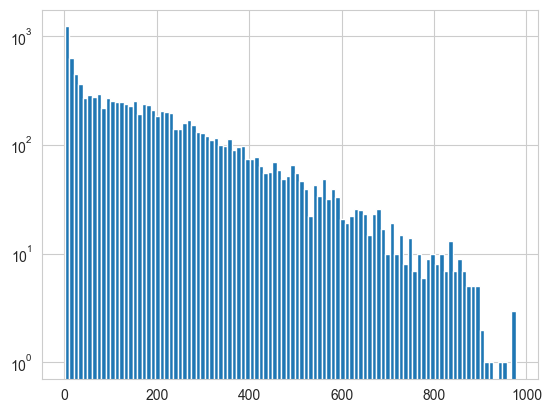

In [23]:
df['count'].hist(bins=100, log=True)

### 2.
Для каждой метрики найдите среднее, дисперсию, 50, 75 и 99 перцентили, моду. Какие выводы о наличии аномалий мы можем сделать?

In [24]:
### YOUR CODE HERE ###
def my_basic_research(df=df, column = "temp"):
    print("Базовые метрики")
    print(df[column].describe())
    print("------------------------------------")

my_basic_research()
my_basic_research(column="atemp")
my_basic_research(column="humidity")
my_basic_research(column="windspeed")
my_basic_research(column="casual")
my_basic_research(column="registered")
my_basic_research(column="count")


Базовые метрики
count    10886.00000
mean        20.23086
std          7.79159
min          0.82000
25%         13.94000
50%         20.50000
75%         26.24000
max         41.00000
Name: temp, dtype: float64
------------------------------------
Базовые метрики
count    10886.000000
mean        23.655084
std          8.474601
min          0.760000
25%         16.665000
50%         24.240000
75%         31.060000
max         45.455000
Name: atemp, dtype: float64
------------------------------------
Базовые метрики
count    10886.000000
mean        61.886460
std         19.245033
min          0.000000
25%         47.000000
50%         62.000000
75%         77.000000
max        100.000000
Name: humidity, dtype: float64
------------------------------------
Базовые метрики
count    10886.000000
mean        12.799395
std          8.164537
min          0.000000
25%          7.001500
50%         12.998000
75%         16.997900
max         56.996900
Name: windspeed, dtype: float64
-----------

In [6]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [25]:
print(np.percentile(df['temp'], 99))
print(np.percentile(df['atemp'], 99))
print(np.percentile(df['humidity'], 99))
print(np.percentile(df['windspeed'], 99))
print(np.percentile(df['casual'], 99))
print(np.percentile(df['registered'], 99))
print(np.percentile(df['count'], 99))

36.08
40.15
100.0
35.0008
240.14999999999964
697.0
774.1499999999996


In [26]:
def my_norm_confidence(df=df, column = "temp", alpha = 0.95):
    interval = stats.norm.interval(alpha, loc=df[column].mean(), scale=df[column].std())
    return interval

In [33]:
confidence = my_norm_confidence()
print(confidence)
anomaly_df = pd.DataFrame()
anomaly_df["temp"] = np.where(df.temp > confidence[1], 1,0)

confidence = my_norm_confidence(column='atemp')
anomaly_df["atemp"] = np.where(df.atemp > confidence[1], 1,0)
anomaly_df[anomaly_df.temp == 1].describe()

(np.float64(4.959624343428539), np.float64(35.50209529647592))


,temp,atemp
count,117.0,117.000000
mean,1.0,0.726496
std,0.0,0.447675
min,1.0,0.000000
25%,1.0,0.000000
50%,1.0,1.000000
75%,1.0,1.000000
max,1.0,1.000000


### 3. (*) 
 Для каждой метрики проанализируйте ассиметрию и смещенность распределения – для этого посчитайте для каждой метрики коэффициент ассиметрии и эксцесса.

In [38]:
### YOUR CODE HERE ###
print(kurtosis(df['temp']))
print(skew(df['temp']))
print(kurtosis(df['atemp']))
print(skew(df['atemp']))
print(kurtosis(df['humidity']))
print(skew(df['humidity']))
print(kurtosis(df['windspeed']))
print(skew(df['windspeed']))
print(kurtosis(df['casual']))
print(skew(df['casual']))
print(kurtosis(df['registered']))
print(skew(df['registered']))
print(kurtosis(df['count']))
print(skew(df['count']))

-0.9146613849825282
0.0036903358354289715
-0.8502363689497141
-0.10254538108264065
-0.760019710012902
-0.0863232869219358
0.629292367034056
0.5886853963635482
7.547610130561701
2.495404491505502
2.6243238654959855
1.5245944734221468
1.2989447727380323
1.241895058803035


### 4.

Постройте симметричный доверительный интервал для метрики с самой большой дисперсией при доверительной вероятности 0.95. 

Базовые метрики
count    10886.000000
mean        36.021955
std         49.960477
min          0.000000
25%          4.000000
50%         17.000000
75%         49.000000
max        367.000000
Name: casual, dtype: float64
------------------------------------
Самые популярные значения метрики, топ 5
casual
0    986
1    667
2    487
3    438
4    354
Name: count, dtype: int64
------------------------------------
Эксцесс  7.547610130561701
Ассиметрия  2.495404491505502


C:\Users\Admin\AppData\Local\Temp\ipykernel_6072\2682576357.py:14: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[column])


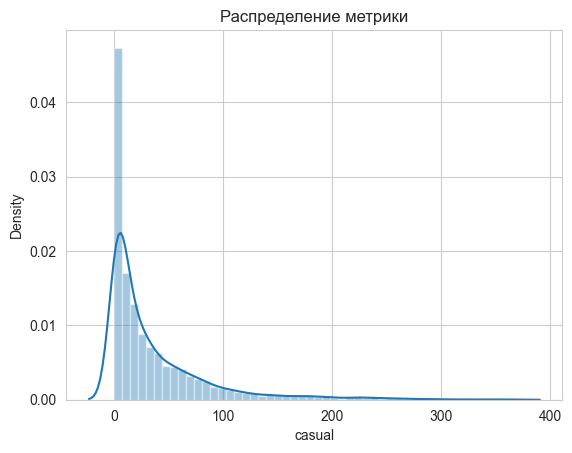

In [2]:
### YOUR CODE HERE ###
def my_basic_research2(df=df, column = "casual"):
    print("Базовые метрики")
    print(df[column].describe())
    print("------------------------------------")
    
    print("Самые популярные значения метрики, топ 5")
    print(df[column].value_counts().nlargest(5))
    print("------------------------------------")
    
    print("Эксцесс ", kurtosis(df[column]))
    print("Ассиметрия ", skew(df[column]))
    
    sns.distplot(df[column])
    plt.title("Распределение метрики")
my_basic_research2()

In [2]:
def my_norm_confidence(df=df, column = "casual", alpha = 0.95):
    interval = stats.norm.interval(alpha, loc=df[column].mean(), scale=df[column].std())
    return interval
confidence = my_norm_confidence()
print(confidence)

(np.float64(-61.89877992851435), np.float64(133.94268953718603))


C:\Users\Admin\AppData\Local\Temp\ipykernel_8700\3509246384.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.casual)


Text(0.5, 1.0, 'Доверительный интервал')

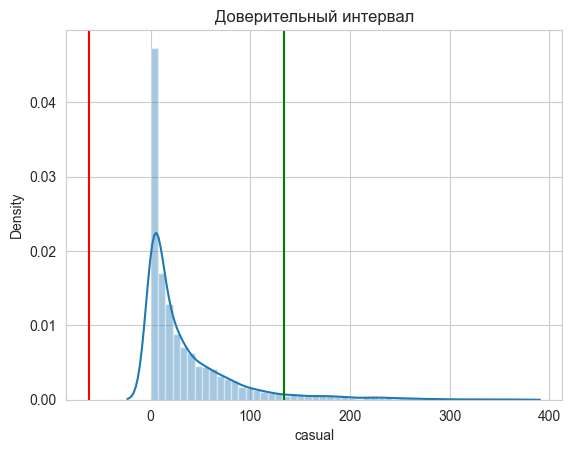

In [5]:
sns.distplot(df.casual)
plt.axvline(x=confidence[1], color="g", linestyle="-")
plt.axvline(x=confidence[0], color="r", linestyle="-")
plt.title("Доверительный интервал")

### 5. (*)

Найдите количество значений, выходящих за три сигмы для каждой из метрик. Где получилось больше всего аномалий?

In [13]:
### YOUR CODE HERE ###
research_list = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']
def anomaly_confidence(df=df):
    for i in research_list:
        upper_level = df[i].mean() + 3*df[i].std()
        print(i)
        c = df[df[i] >= upper_level].count()
        print(c[i])
anomaly_confidence()
# print(confidence)
# stat_df = pd.DataFrame()
# upper_level_casual = df.casual.mean() + 3*df.casual.std()
# stat_df['casual_stat'] =  df[df.casual >= upper_level_casual].describe()
# stat_df


temp
0
atemp
0
humidity
0
windspeed
67
casual
292
registered
235
count
147


### 6.

Постройте корреляционную матрицу и heatmap по метрикам. Какие выводы о наличии связей можно сделать?

<Axes: >

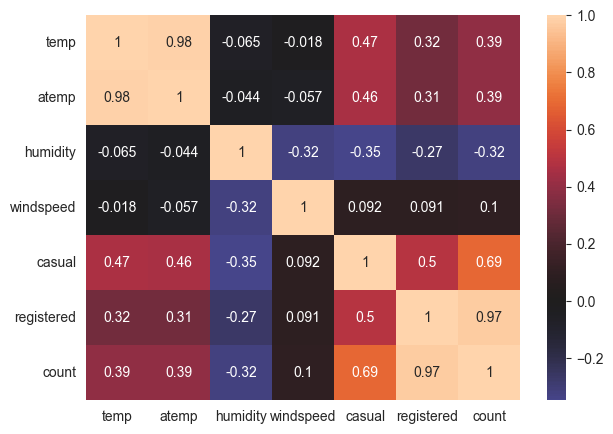

In [10]:
### YOUR CODE HERE ###
corr_m = df[research_list].corr()
plt.figure(figsize=(7,5))
sns.heatmap(corr_m, center=0, annot=True)